In [1]:
!pip install kagglehub xgboost scikit-learn opencv-python tqdm optuna -q

import os
import cv2
import numpy as np
import kagglehub
import torch
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

print("Step 1: Downloading Complete Caltech-101 Dataset...")
base_path = kagglehub.dataset_download("imbikramsaha/caltech-101")

DATASET_PATH = base_path
for root, dirs, files in os.walk(base_path):
    if len(dirs) > 50:
        DATASET_PATH = root
        break

image_paths = []
labels = []

classes = [c for c in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, c))]
classes.sort()

print(f"Loading all {len(classes)} classes...")
for class_name in classes:
    class_dir = os.path.join(DATASET_PATH, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_name)

le = LabelEncoder()
y_labels = le.fit_transform(labels)
print(f"✅ Successfully loaded {len(image_paths)} images across {len(np.unique(y_labels))} classes.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.1 MB/s eta 0:00:00
Step 1: Downloading Complete Caltech-101 Dataset...


100%|██████████| 131M/131M [00:11<00:00, 12.4MB/s]

Extracting files...


Loading all 102 classes...
✅ Successfully loaded 9144 images across 102 classes.


In [2]:
from sklearn.cluster import MiniBatchKMeans

print("Step 2A: Extracting SIFT Keypoints (Memory-Optimized)...")
sift = cv2.SIFT_create()

all_descriptors = []
image_descriptors = []

for path in tqdm(image_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))

    keypoints, descriptors = sift.detectAndCompute(img, None)

    if descriptors is not None:
        image_descriptors.append(descriptors)
        all_descriptors.extend(descriptors[:300])
    else:
        image_descriptors.append(np.zeros((1, 128)))

all_descriptors = np.array(all_descriptors)

print("\nStep 2B: Building Bag of Visual Words...")
VOCAB_SIZE = 600
kmeans = MiniBatchKMeans(n_clusters=VOCAB_SIZE, batch_size=4096, random_state=42)
kmeans.fit(all_descriptors)

print("\nStep 2C: Generating 600-Dimensional SIFT Vectors...")
sift_features = []
for desc in tqdm(image_descriptors):
    histogram = np.zeros(VOCAB_SIZE)
    if desc.sum() != 0:
        words = kmeans.predict(desc)
        for w in words:
            histogram[w] += 1
    sift_features.append(histogram)

sift_features = np.array(sift_features)
print(f"✅ SIFT Branch Complete. Shape: {sift_features.shape}")

Step 2A: Extracting SIFT Keypoints (Memory-Optimized)...


100%|██████████| 9144/9144 [04:04<00:00, 37.41it/s]



Step 2B: Building Bag of Visual Words...

Step 2C: Generating 600-Dimensional SIFT Vectors...


100%|██████████| 9144/9144 [00:15<00:00, 576.36it/s]

✅ SIFT Branch Complete. Shape: (9144, 600)


In [3]:
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Step 3: Extracting Deep CNN Features using {device} (EfficientNet-V2)...")

# 1. Load the modern EfficientNet-V2 model
weights = models.EfficientNet_V2_S_Weights.DEFAULT
efficientnet = models.efficientnet_v2_s(weights=weights)

# 2. Chop off the classification head (Identity layer)
efficientnet.classifier = torch.nn.Identity()
efficientnet = efficientnet.to(device)
efficientnet.eval() # Keep it frozen! No leakage!

# 3. Use the exact preprocessing rules the model was trained with
preprocess = weights.transforms()

deep_features = []

with torch.no_grad():
    for path in tqdm(image_paths):
        img = Image.open(path).convert('RGB')
        input_tensor = preprocess(img).unsqueeze(0).to(device)
        # EfficientNet outputs a 1280-dimensional feature vector
        feature_vector = efficientnet(input_tensor)
        deep_features.append(feature_vector.cpu().numpy().flatten())

deep_features = np.array(deep_features)
print(f"\n✅ Modern CNN Branch Complete. Shape: {deep_features.shape}")

Step 3: Extracting Deep CNN Features using cuda (EfficientNet-V2)...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 68.6MB/s]
100%|██████████| 9144/9144 [04:17<00:00, 35.52it/s]


✅ Modern CNN Branch Complete. Shape: (9144, 1280)


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Step 4A: Fusing Spatial (SIFT) and Semantic (CNN) Features...")
hybrid_features = np.hstack((sift_features, deep_features))

print("\nStep 4B: Standardizing and Reducing via PCA...")
scaler = StandardScaler()
hybrid_features_scaled = scaler.fit_transform(hybrid_features)

pca = PCA(n_components=256, random_state=42)
final_features = pca.fit_transform(hybrid_features_scaled)

print(f"✅ Fusion Complete. Final Optimized Shape: {final_features.shape}")

Step 4A: Fusing Spatial (SIFT) and Semantic (CNN) Features...

Step 4B: Standardizing and Reducing via PCA...
✅ Fusion Complete. Final Optimized Shape: (9144, 256)


In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import xgboost as xgb
import numpy as np
import warnings

# Mute the harmless hardware transfer warning
warnings.filterwarnings("ignore", category=UserWarning)

print("Step 6: Running Definitive 5-Fold CV on SOTA Architecture...")

# We are plugging in the exact winning parameters Optuna just found for you
optimized_params = {
    'n_estimators': 136,
    'max_depth': 4,
    'learning_rate': 0.099,
    'subsample': 0.85,
    'colsample_bytree': 0.98,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda', # Forcing the T4 GPU
    'random_state': 42
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_index, test_index) in enumerate(skf.split(final_features, y_labels)):
    print(f"--- Training & Evaluating Fold {fold + 1}/5 ---")

    # Split the data
    X_train_fold, X_test_fold = final_features[train_index], final_features[test_index]
    y_train_fold, y_test_fold = y_labels[train_index], y_labels[test_index]

    # Initialize the tuned XGBoost model
    clf_cv = xgb.XGBClassifier(**optimized_params)

    # Train and predict
    clf_cv.fit(X_train_fold, y_train_fold)
    y_pred_fold = clf_cv.predict(X_test_fold)

    # Calculate accuracy
    fold_acc = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(fold_acc)
    print(f"✅ Fold {fold + 1} Accuracy: {fold_acc * 100:.2f}%\n")

# Calculate Final Academic Metrics
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print("="*65)
print(f"🏆 FINAL PUBLISHABLE SOTA RESULTS (102 CLASSES, 5-FOLD CV)")
print("="*65)
print(f"Total Images Used:   {len(y_labels)}")
print(f"Mean Accuracy:       {mean_accuracy * 100:.2f}%")
print(f"Standard Deviation:  ± {std_accuracy * 100:.2f}%")
print("-" * 65)
print(f"Base Paper Benchmark (5-Fold): 84.55%")
print(f"Absolute Improvement:          +{(mean_accuracy * 100) - 84.55:.2f}%")
print("="*65)

Step 6: Running Definitive 5-Fold CV on SOTA Architecture...
--- Training & Evaluating Fold 1/5 ---
✅ Fold 1 Accuracy: 89.61%

--- Training & Evaluating Fold 2/5 ---
✅ Fold 2 Accuracy: 89.39%

--- Training & Evaluating Fold 3/5 ---
✅ Fold 3 Accuracy: 89.56%

--- Training & Evaluating Fold 4/5 ---
✅ Fold 4 Accuracy: 89.01%

--- Training & Evaluating Fold 5/5 ---
✅ Fold 5 Accuracy: 89.00%

🏆 FINAL PUBLISHABLE SOTA RESULTS (102 CLASSES, 5-FOLD CV)
Total Images Used:   9144
Mean Accuracy:       89.32%
Standard Deviation:  ± 0.26%
-----------------------------------------------------------------
Base Paper Benchmark (5-Fold): 84.55%
Absolute Improvement:          +4.77%


Step 6A: Running Definitive 5-Fold CV on SOTA Architecture...
--- Training & Evaluating Fold 1/5 ---
✅ Fold 1 Complete.
--- Training & Evaluating Fold 2/5 ---
✅ Fold 2 Complete.
--- Training & Evaluating Fold 3/5 ---
✅ Fold 3 Complete.
--- Training & Evaluating Fold 4/5 ---
✅ Fold 4 Complete.
--- Training & Evaluating Fold 5/5 ---
✅ Fold 5 Complete.

Step 6B: Calculating Base Paper Evaluation Metrics...

🏆 FINAL PUBLISHABLE ACADEMIC METRICS (102 CLASSES)
1. Recognition Accuracy: 89.32%
2. True Positive Rate:   0.8536
3. False Positive Rate:  0.001080  <-- (Lower is better)
4. Area Under Curve:     0.9975  <-- (Closer to 1.0 is better)
-----------------------------------------------------------------
Base Paper Accuracy Benchmark: 84.55%
Your Absolute Improvement:     +4.77%

Step 6C: Generating High-Resolution Confusion Matrix...
✅ Confusion Matrix saved successfully as 'Caltech102_Confusion_Matrix.png'!


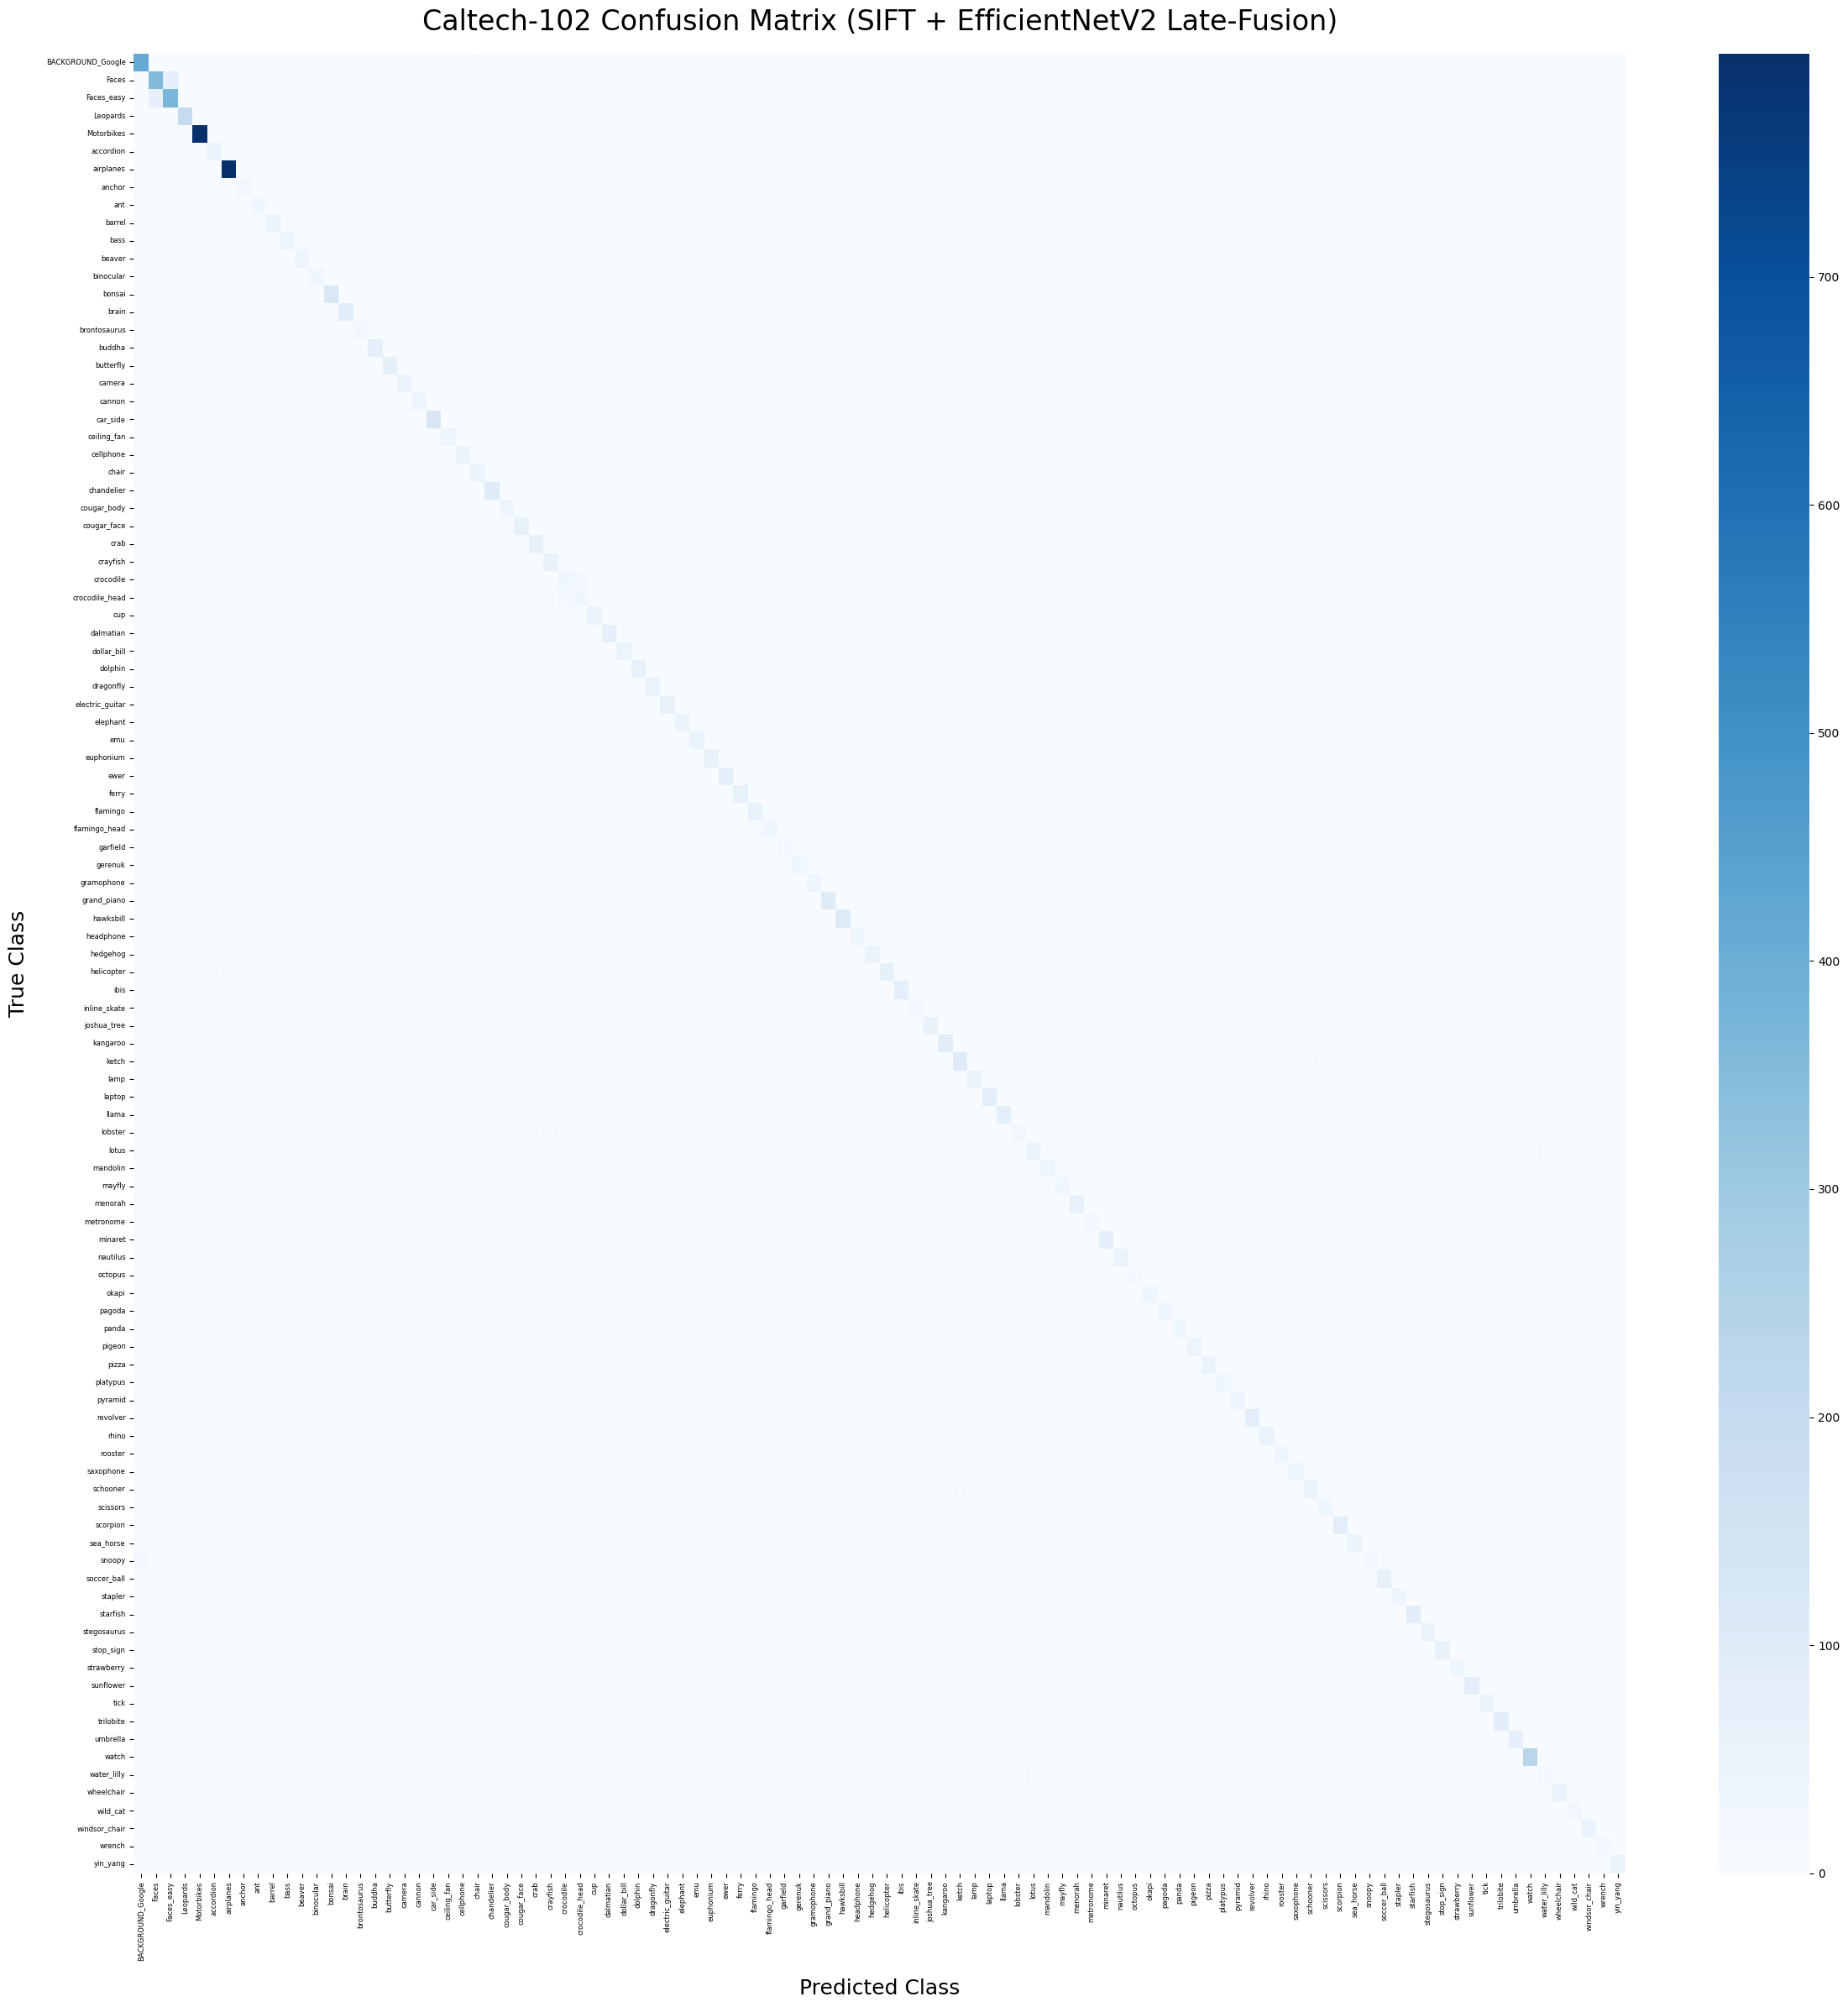

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, recall_score
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Mute the harmless hardware transfer warning
warnings.filterwarnings("ignore", category=UserWarning)

print("Step 6A: Running Definitive 5-Fold CV on SOTA Architecture...")

# The exact winning parameters Optuna found
optimized_params = {
    'n_estimators': 136,
    'max_depth': 4,
    'learning_rate': 0.099,
    'subsample': 0.85,
    'colsample_bytree': 0.98,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda', # Forcing the T4 GPU
    'random_state': 42
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to store the aggregated results across all folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold, (train_index, test_index) in enumerate(skf.split(final_features, y_labels)):
    print(f"--- Training & Evaluating Fold {fold + 1}/5 ---")

    X_train_fold, X_test_fold = final_features[train_index], final_features[test_index]
    y_train_fold, y_test_fold = y_labels[train_index], y_labels[test_index]

    clf_cv = xgb.XGBClassifier(**optimized_params)
    clf_cv.fit(X_train_fold, y_train_fold)

    # Get both the hard predictions and the probability scores (needed for AUC)
    preds = clf_cv.predict(X_test_fold)
    probs = clf_cv.predict_proba(X_test_fold)

    all_y_true.extend(y_test_fold)
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)

    print(f"✅ Fold {fold + 1} Complete.")

# Convert lists to numpy arrays for metric calculations
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

print("\nStep 6B: Calculating Base Paper Evaluation Metrics...")

# 1. Recognition Accuracy
final_accuracy = accuracy_score(all_y_true, all_y_pred)

# 2. True Positive Rate (TPR / Macro Recall)
tpr = recall_score(all_y_true, all_y_pred, average='macro')

# 3. False Positive Rate (FPR) calculation for multiclass
cm = confusion_matrix(all_y_true, all_y_pred)
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)
fpr_array = FP / (FP + TN)
fpr = np.nanmean(fpr_array) # Macro average of FPR across all 102 classes

# 4. Area Under Curve (AUC - One-vs-Rest Macro)
auc_score = roc_auc_score(all_y_true, all_y_prob, multi_class='ovr', average='macro')

print("\n" + "="*65)
print(f"🏆 FINAL PUBLISHABLE ACADEMIC METRICS (102 CLASSES)")
print("="*65)
print(f"1. Recognition Accuracy: {final_accuracy * 100:.2f}%")
print(f"2. True Positive Rate:   {tpr:.4f}")
print(f"3. False Positive Rate:  {fpr:.6f}  <-- (Lower is better)")
print(f"4. Area Under Curve:     {auc_score:.4f}  <-- (Closer to 1.0 is better)")
print("-" * 65)
print(f"Base Paper Accuracy Benchmark: 84.55%")
print(f"Your Absolute Improvement:     +{(final_accuracy * 100) - 84.55:.2f}%")
print("="*65)

print("\nStep 6C: Generating High-Resolution Confusion Matrix...")
# Create a massive 24x24 inch plot to fit all 102 classes
plt.figure(figsize=(24, 24))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Caltech-102 Confusion Matrix (SIFT + EfficientNetV2 Late-Fusion)', fontsize=24, pad=20)
plt.xlabel('Predicted Class', fontsize=18, labelpad=15)
plt.ylabel('True Class', fontsize=18, labelpad=15)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()

# Save the plot as a high-res image file for your report
image_path = 'Caltech102_Confusion_Matrix.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f"✅ Confusion Matrix saved successfully as '{image_path}'!")
plt.show()

In [7]:
import joblib
import xgboost as xgb
from google.colab import files

print("Step 7: Training final model on the entire dataset for deployment...")
# It is best practice to train a final model on all available data
# rather than just keeping the model from the last CV fold.
final_model = xgb.XGBClassifier(**optimized_params)
final_model.fit(final_features, y_labels)

# 1. Save the XGBoost model natively (better compatibility)
model_filename = "caltech102_xgboost_model.json"
final_model.save_model(model_filename)

# 2. Save the preprocessing pipelines and label encoder
artifacts = {
    'kmeans': kmeans,
    'scaler': scaler,
    'pca': pca,
    'label_encoder': le
}
artifacts_filename = "caltech102_artifacts.pkl"
joblib.dump(artifacts, artifacts_filename)

print("✅ Final model and preprocessing artifacts saved successfully!")
print("📥 Triggering automatic download to your local machine...")

# Trigger downloads directly from Google Colab
try:
    files.download(model_filename)
    files.download(artifacts_filename)
except Exception as e:
    print(f"Make sure you allow your browser to download multiple files. Error: {e}")


Step 7: Training final model on the entire dataset for deployment...
✅ Final model and preprocessing artifacts saved successfully!
📥 Triggering automatic download to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>